In [17]:
import os
import glob
import numpy as np
import uproot

import matplotlib.pyplot as plt
import mplhep as hep

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import log_loss, roc_auc_score, roc_curve

# ------------------- CMS style -------------------
plt.style.use(hep.style.CMS)
YEAR = "2024"
ENERGY = "13.6 TeV"

def add_cms_sim_label(ax):
    hep.cms.label(
        ax=ax,
        data=False,
        llabel="Simulation",
        rlabel=f"{YEAR} ({ENERGY})",
        fontname="sans-serif",
    )

# ------------------- I/O -------------------
INPUT_DIR  = "/Users/artemis/desktop/jmar_trees"
#INPUT_DIR  = "/eos/cms/store/group/phys_jetmet/ataxeidi/20251024_ULNanoV15_gen_hadron_nsubs_bbb_ccc_ak8_qcd_2024/mc"
TREE_NAME  = "Events"
OUTPUT_DIR = "./sfbdt_qcd_training"
os.makedirs(OUTPUT_DIR, exist_ok=True)

input_patterns = [
    "qcd-bbb-enriched_tree.root",
    "qcd-ccc-enriched_tree.root",
]

INPUT_FILES = []
for pat in input_patterns:
    INPUT_FILES.extend(glob.glob(os.path.join(INPUT_DIR, pat)))
print(f"Found {len(INPUT_FILES)} input files.")


Found 2 input files.


In [25]:
# ------------------- Config -------------------
TAU31_CUT = 0.1
KFOLD = 5
RNG = 42
np.random.seed(RNG)

FEATURE_NAMES = [
    "tau21",
    "sj1_rawmass",
    "sj2_rawmass",
    "ntracks_sv12",
    "sj1_sv1_pt",
    "sj2_sv1_pt",
]

# =================== Helpers ===================

def compute_tau31(gen_tau3, gen_tau1):
    """Compute tau3/tau1 safely; return (tau31, valid_mask)."""
    gen_tau3 = np.asarray(gen_tau3, dtype=float)
    gen_tau1 = np.asarray(gen_tau1, dtype=float)
    valid = np.isfinite(gen_tau1) & np.isfinite(gen_tau3) & (gen_tau1 > 0)
    tau31 = np.full_like(gen_tau1, np.nan, dtype=float)
    tau31[valid] = gen_tau3[valid] / gen_tau1[valid]
    valid = valid & np.isfinite(tau31)
    return tau31, valid

def make_1d_hist(
    values_sig,
    values_bkg,
    bins,
    xlabel,
    outname,
    sig_label=None,
    bkg_label=None,
    logy=False,
):
    """ histogram comparison plot """
    if sig_label is None:
        sig_label = f"Sig-like jets (tau31 < {TAU31_CUT})"
    if bkg_label is None:
        bkg_label = f"Bkg-like jets (tau31 > {TAU31_CUT})"

    fig, ax = plt.subplots(figsize=(8, 8))
    add_cms_sim_label(ax)

    values_sig = values_sig[np.isfinite(values_sig)]
    values_bkg = values_bkg[np.isfinite(values_bkg)]

    ax.hist(values_bkg, bins=bins, histtype="stepfilled", alpha=0.5, label=bkg_label, density=True)
    ax.hist(values_sig, bins=bins, histtype="step", linewidth=1.5, label=sig_label, density=True)

    ax.set_xlabel(xlabel, ha="right", x=1.0)
    ax.set_ylabel("1/N dN/dx", ha="right", y=1.0)
    ax.legend()

    if logy:
        ax.set_yscale("log")
        ax.set_ylim(1e-4, ax.get_ylim()[1] * 10)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, outname))
    plt.show()


In [26]:
# =================== Loader (JET-LEVEL selection only) ===================

def load_file_as_jets(filename):
    """
    Build per-jet training rows 

    Selection:
      - keep jets that satisfy:
          * fj_x_is_qualified 
          * fj_x_sj1_sv1_pt > 0 and fj_x_sj2_sv1_pt > 0
          * reco tau21 finite and in [0,1]
          * GEN tau31 valid and label (<cut or >cut)

    Labels:
      y = 1 if tau31 < TAU31_CUT else 0 if tau31 > TAU31_CUT
    """
    print(f"Loading {filename}")
    with uproot.open(filename) as f:
        if TREE_NAME not in f:
            print(f"  [WARNING] Tree {TREE_NAME} not found in {filename}, skipping.")
            return None, None

        tree = f[TREE_NAME]
        branches = [
            # reco-level inputs
            "fj_1_tau1", "fj_1_tau2",
            "fj_2_tau1", "fj_2_tau2",

            "fj_1_sj1_rawmass", "fj_1_sj2_rawmass",
            "fj_2_sj1_rawmass", "fj_2_sj2_rawmass",

            "fj_1_ntracks_sv12", "fj_2_ntracks_sv12",
            "fj_1_sj1_sv1_pt", "fj_1_sj2_sv1_pt",
            "fj_2_sj1_sv1_pt", "fj_2_sj2_sv1_pt",

            # qualification requirement (pre-BDT)
            "fj_1_is_qualified", "fj_2_is_qualified",

            # GEN-level for labels
            "fj_1_gen_hadron_tau1", "fj_1_gen_hadron_tau3",
            "fj_2_gen_hadron_tau1", "fj_2_gen_hadron_tau3",
        ]

        arr = tree.arrays(branches, library="np")

    # reco tau21 with NaN for invalid tau1
    tau21_fj1 = np.full_like(arr["fj_1_tau1"], np.nan, dtype=float)
    m1 = arr["fj_1_tau1"] > 0
    tau21_fj1[m1] = arr["fj_1_tau2"][m1] / arr["fj_1_tau1"][m1]

    tau21_fj2 = np.full_like(arr["fj_2_tau1"], np.nan, dtype=float)
    m2 = arr["fj_2_tau1"] > 0
    tau21_fj2[m2] = arr["fj_2_tau2"][m2] / arr["fj_2_tau1"][m2]

    arr["fj_1_tau21"] = tau21_fj1
    arr["fj_2_tau21"] = tau21_fj2

    X_list, y_list = [], []

    for jidx in [1, 2]:
        prefix = f"fj_{jidx}_"

        tau21        = arr[prefix + "tau21"]
        sj1_rawmass  = arr[prefix + "sj1_rawmass"]
        sj2_rawmass  = arr[prefix + "sj2_rawmass"]
        ntracks_sv12 = arr[prefix + "ntracks_sv12"]
        sj1_sv1_pt   = arr[prefix + "sj1_sv1_pt"]
        sj2_sv1_pt   = arr[prefix + "sj2_sv1_pt"]

        isqual = arr[prefix + "is_qualified"].astype(bool)

        gen_tau1 = arr[prefix + "gen_hadron_tau1"]
        gen_tau3 = arr[prefix + "gen_hadron_tau3"]

        tau31, valid_gen = compute_tau31(gen_tau3, gen_tau1)
        is_sig = tau31 < TAU31_CUT
        is_bkg = tau31 > TAU31_CUT
        keep_gen = valid_gen & (is_sig | is_bkg)

        valid_tau21 = np.isfinite(tau21) & (tau21 >= 0.0) & (tau21 <= 1.0)
        valid_sv = (
            np.isfinite(sj1_sv1_pt) & np.isfinite(sj2_sv1_pt) &
            (sj1_sv1_pt > 0.0) & (sj2_sv1_pt > 0.0)
        )

        keep = isqual & valid_tau21 & keep_gen & valid_sv
        if not np.any(keep):
            continue

        features = np.column_stack([
            tau21[keep],
            sj1_rawmass[keep],
            sj2_rawmass[keep],
            ntracks_sv12[keep],
            sj1_sv1_pt[keep],
            sj2_sv1_pt[keep],
        ])
        labels = is_sig[keep].astype(int)

        X_list.append(features)
        y_list.append(labels)

    if not X_list:
        return None, None

    X_file = np.concatenate(X_list, axis=0)
    y_file = np.concatenate(y_list, axis=0)
    print(f"  -> {X_file.shape[0]} jets from {os.path.basename(filename)}")
    return X_file, y_file


In [27]:
# =================== Load & merge ===================

all_X, all_y = [], []
for fpath in INPUT_FILES:
    Xf, yf = load_file_as_jets(fpath)
    if Xf is None:
        continue
    all_X.append(Xf)
    all_y.append(yf)

if not all_X:
    raise RuntimeError("No jets collected! Check inputs and branches names")

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

print("\nFinal dataset:")
print("  X shape:", X.shape)
print("  y shape:", y.shape)
print("  Signal jets:    ", np.sum(y == 1))
print("  Background jets:", np.sum(y == 0))


Loading /Users/artemis/desktop/jmar_trees/qcd-bbb-enriched_tree.root
  -> 108330 jets from qcd-bbb-enriched_tree.root
Loading /Users/artemis/desktop/jmar_trees/qcd-ccc-enriched_tree.root
  -> 53906 jets from qcd-ccc-enriched_tree.root

Final dataset:
  X shape: (162236, 6)
  y shape: (162236,)
  Signal jets:     21756
  Background jets: 140480


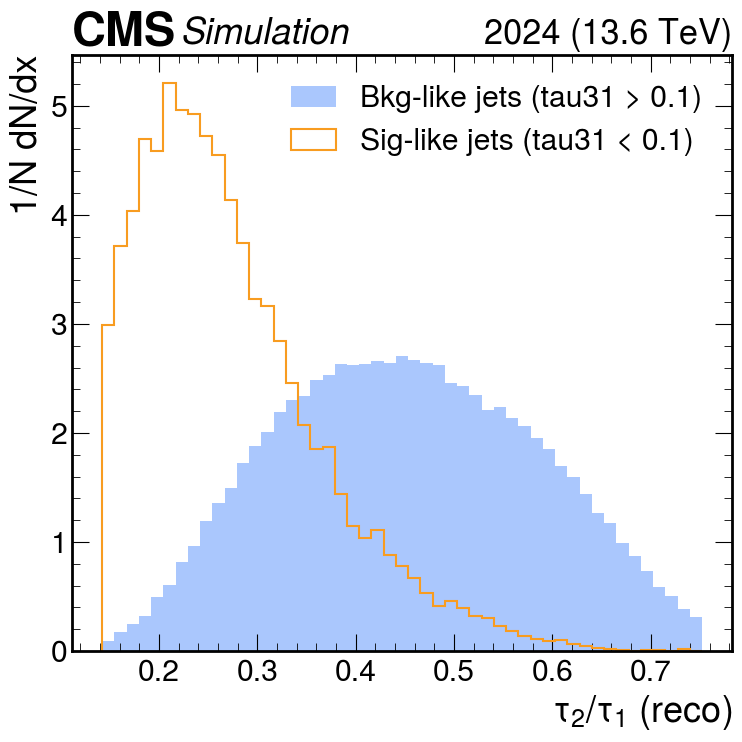

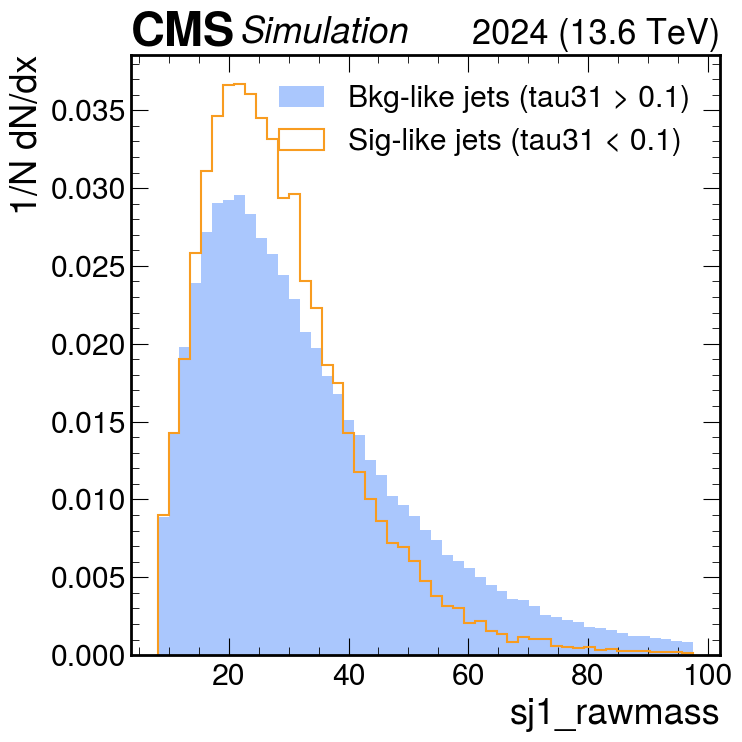

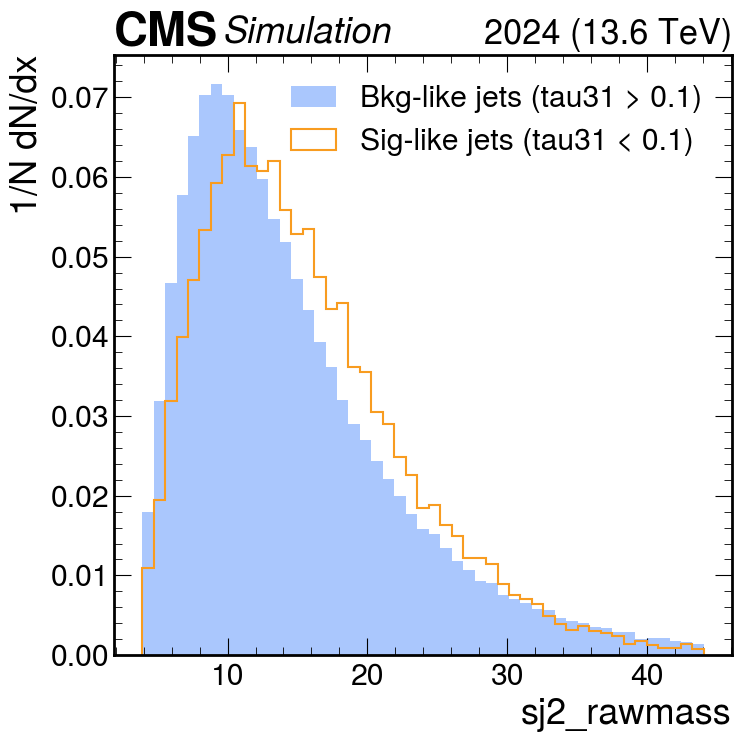

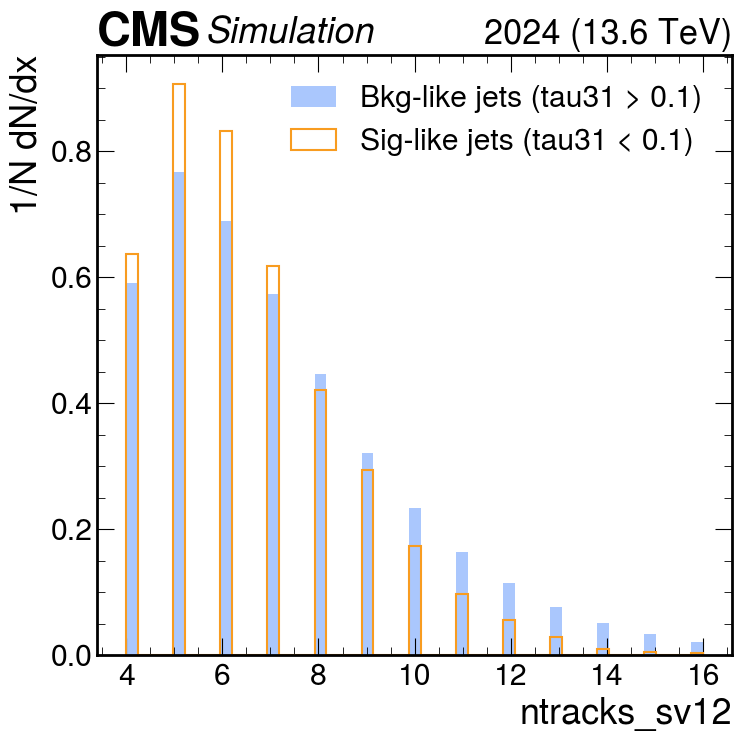

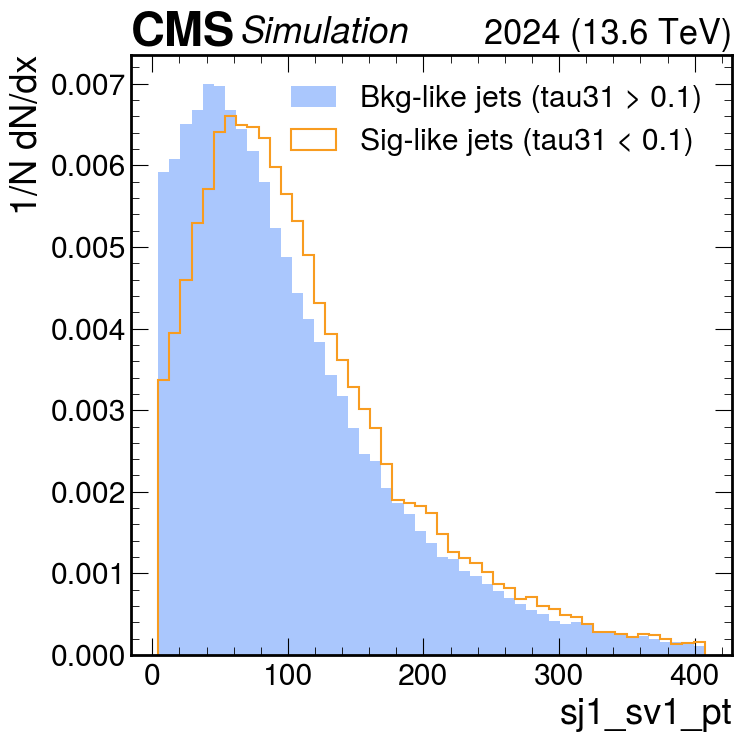

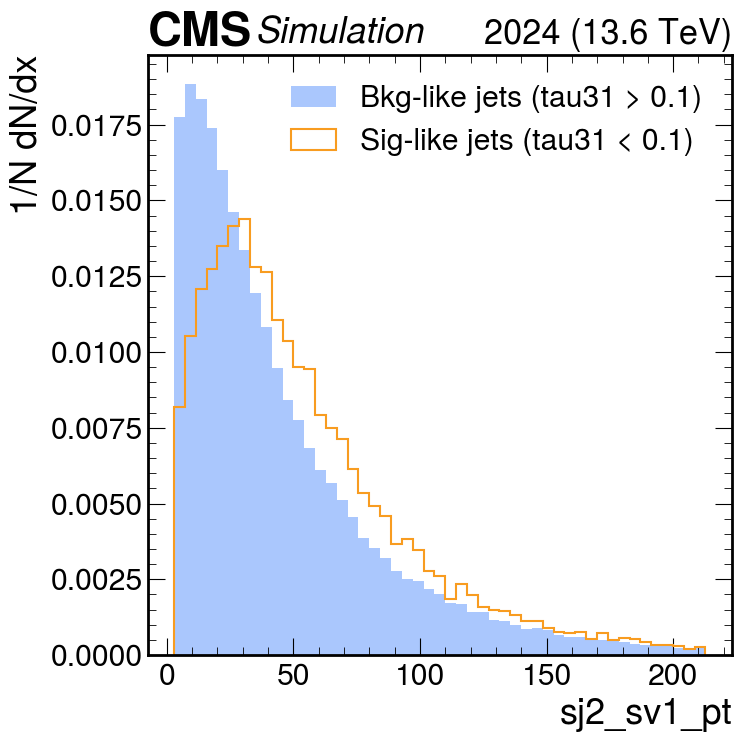

Reading GEN tau for tau31 plot from /Users/artemis/desktop/jmar_trees/qcd-bbb-enriched_tree.root
Reading GEN tau for tau31 plot from /Users/artemis/desktop/jmar_trees/qcd-ccc-enriched_tree.root
tau31_sig size: 21756
tau31_bkg size: 140480


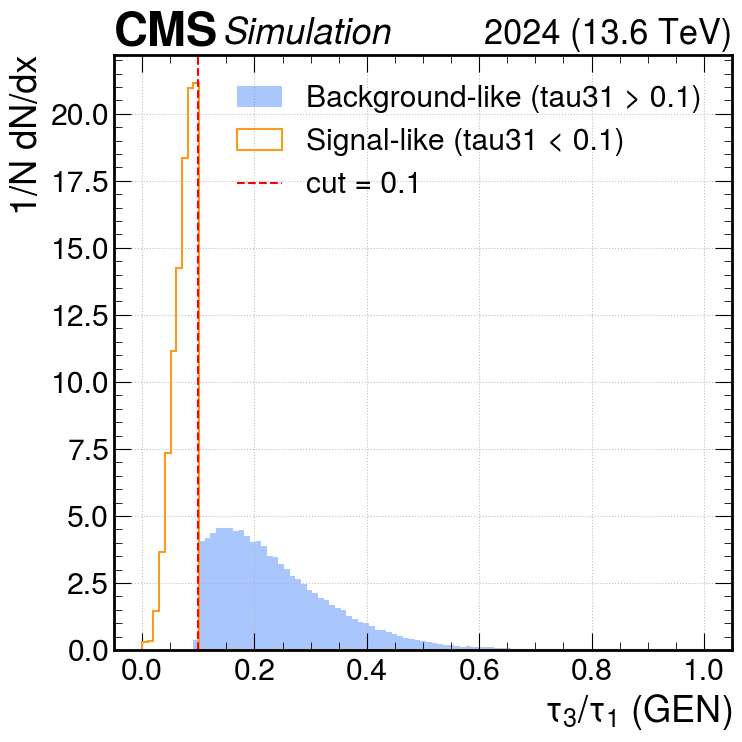

In [28]:
# =================== Feature plots ===================

for i, fname in enumerate(FEATURE_NAMES):
    x_sig = X[y == 1, i]
    x_bkg = X[y == 0, i]

    x_all = np.concatenate([x_sig, x_bkg])
    x_all = x_all[np.isfinite(x_all)]
    if x_all.size == 0:
        continue

    xmin, xmax = np.percentile(x_all, [1, 99])
    bins = np.linspace(xmin, xmax, 50)

    xlabel = fname
    if fname == "tau21":
        xlabel = r"$\tau_{2}/\tau_{1}$ (reco)"

    make_1d_hist(
        x_sig,
        x_bkg,
        bins,
        xlabel=xlabel,
        outname=f"input_{fname}_sig_vs_bkg.pdf",
    )

# =================== tau31 (GEN) plot  ===================

all_tau31_sig, all_tau31_bkg = [], []

for fpath in INPUT_FILES:
    print(f"Reading GEN tau for tau31 plot from {fpath}")
    with uproot.open(fpath) as f:
        if TREE_NAME not in f:
            print(f"  [WARNING] Tree {TREE_NAME} not found in {fpath}, skipping.")
            continue

        tree = f[TREE_NAME]
        branches = [
            "fj_1_is_qualified", "fj_2_is_qualified",
            "fj_1_sj1_sv1_pt", "fj_1_sj2_sv1_pt",
            "fj_2_sj1_sv1_pt", "fj_2_sj2_sv1_pt",
            "fj_1_gen_hadron_tau1", "fj_1_gen_hadron_tau3",
            "fj_2_gen_hadron_tau1", "fj_2_gen_hadron_tau3",
        ]
        arr = tree.arrays(branches, library="np")

        for jidx in [1, 2]:
            prefix = f"fj_{jidx}_"
            isqual = arr[prefix + "is_qualified"].astype(bool)

            sj1_sv1_pt = arr[prefix + "sj1_sv1_pt"]
            sj2_sv1_pt = arr[prefix + "sj2_sv1_pt"]
            valid_sv = (
                np.isfinite(sj1_sv1_pt) & np.isfinite(sj2_sv1_pt) &
                (sj1_sv1_pt > 0.0) & (sj2_sv1_pt > 0.0)
            )

            gen_tau1 = arr[prefix + "gen_hadron_tau1"]
            gen_tau3 = arr[prefix + "gen_hadron_tau3"]
            tau31, valid = compute_tau31(gen_tau3, gen_tau1)

            valid = valid & isqual & valid_sv

            is_sig = tau31 < TAU31_CUT
            is_bkg = tau31 > TAU31_CUT

            all_tau31_sig.append(tau31[valid & is_sig])
            all_tau31_bkg.append(tau31[valid & is_bkg])

tau31_sig = np.concatenate(all_tau31_sig) if all_tau31_sig else np.array([])
tau31_bkg = np.concatenate(all_tau31_bkg) if all_tau31_bkg else np.array([])

tau31_sig = tau31_sig[np.isfinite(tau31_sig)]
tau31_bkg = tau31_bkg[np.isfinite(tau31_bkg)]

print("tau31_sig size:", tau31_sig.size)
print("tau31_bkg size:", tau31_bkg.size)

if tau31_sig.size > 0 and tau31_bkg.size > 0:
    bins = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(8,8))
    add_cms_sim_label(ax)

    ax.hist(
        tau31_bkg,
        bins=bins,
        histtype="stepfilled",
        alpha=0.5,
        label=f"Background-like (tau31 > {TAU31_CUT})",
        density=True,
    )
    ax.hist(
        tau31_sig,
        bins=bins,
        histtype="step",
        linewidth=1.5,
        label=f"Signal-like (tau31 < {TAU31_CUT})",
        density=True,
    )

    ax.axvline(
        TAU31_CUT,
        linestyle="--",
        linewidth=1.5,
        color="red",
        label=f"cut = {TAU31_CUT}",
    )

    ax.set_xlabel(r"$\tau_{3}/\tau_{1}$ (GEN)", ha="right", x=1.0)
    ax.set_ylabel("1/N dN/dx", ha="right", y=1.0)
    ax.grid(True)
    ax.legend()

    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "tau31_sig_vs_bkg_with_cut.pdf"))
    plt.show()
else:
    print("Not  entries to plot.")


Train: (129788, 6) Test: (32448, 6)
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best CV (neg logloss): 0.8965235412791589
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.07, 'gamma': 0.4, 'colsample_bytree': 0.6}

Final XGBoost params for training: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'booster': 'gbtree', 'max_depth': 3, 'eta': 0.07, 'min_child_weight': 3, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 0.4, 'nthread': 4}
num_boost_round (max): 500

=== Training fold 0 / 4 ===
[0]	test-logloss:0.65630
[50]	test-logloss:0.27444
[100]	test-logloss:0.25571
[150]	test-logloss:0.25266
[200]	test-logloss:0.25174
[250]	test-logloss:0.25156
[300]	test-logloss:0.25147
[350]	test-logloss:0.25146
[400]	test-logloss:0.25141
[450]	test-logloss:0.25135
[499]	test-logloss:0.25132
  Fold 0 Train AUC: 0.8985
  Fold 0 Test  AUC: 0.8928
  Saved model to ./sfbdt_qcd_training/xgb_train_qcd.model.0



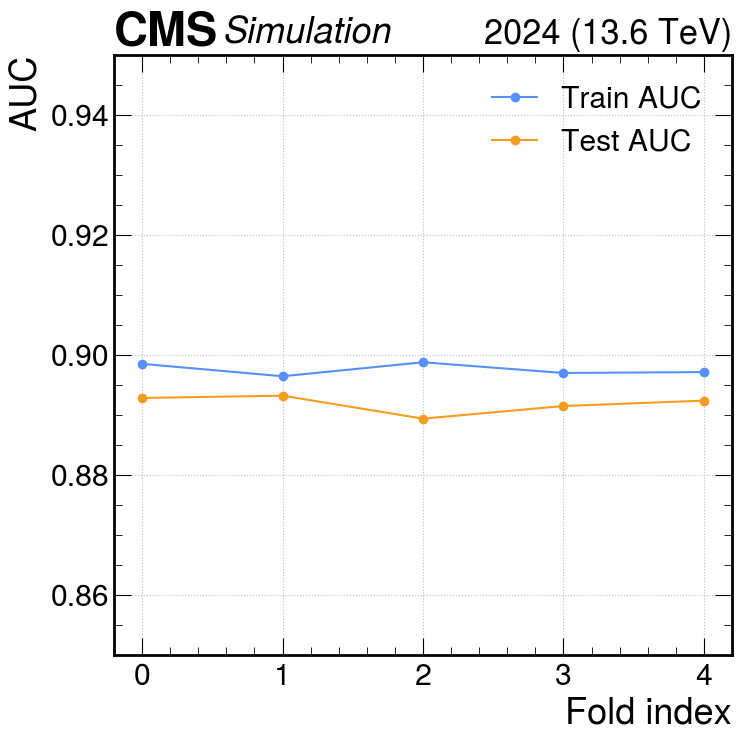

In [29]:

# =================== Train/test split ===================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG
)
print("Train:", X_train.shape, "Test:", X_test.shape)

# =================== Custom scorer ===================

def logloss_scorer(estimator, X_val, y_true):
    y_proba = estimator.predict_proba(X_val)[:, 1]
    return -log_loss(y_true, y_proba)

# =================== Hyperparameter scan ===================

param_dist = {
    "max_depth":        [2, 3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.02,0.03,0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1],
    "n_estimators":     [200, 300, 400, 500, 700],
    "min_child_weight": [1,2, 3,4, 5,6, 7],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma":            [0.0,0.1, 0.2,0.4, 0.5,0.7, 1.0],
}

base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=6,
    random_state=RNG,
)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=100,
    n_jobs=6,
    cv=cv_inner,
    verbose=1,
    refit=True,
    random_state=RNG,
)

search.fit(X_train, y_train)

print("\nBest CV (neg logloss):", search.best_score_)
print("Best params:", search.best_params_)
best_params = search.best_params_

# =================== xgb.train params ===================

xgb_params = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "booster":          "gbtree",
    "max_depth":        best_params["max_depth"],
    "eta":              best_params["learning_rate"],
    "min_child_weight": best_params["min_child_weight"],
    "subsample":        best_params["subsample"],
    "colsample_bytree": best_params["colsample_bytree"],
    "gamma":            best_params["gamma"],
    "nthread":          4,
}
num_boost_round = int(best_params["n_estimators"])

print("\nFinal XGBoost params for training:", xgb_params)
print("num_boost_round (max):", num_boost_round)
# =================== K-fold training with early stopping ===================

kf = StratifiedKFold(n_splits=KFOLD, shuffle=True, random_state=RNG)

train_aucs = []
test_aucs  = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    print(f"\n=== Training fold {fold_idx} / {KFOLD-1} ===")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURE_NAMES)
    dtest  = xgb.DMatrix(X_te, label=y_te, feature_names=FEATURE_NAMES)

    bst = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=[(dtest, "test")],
        early_stopping_rounds=50,
        verbose_eval=50,
    )

    best_iter = bst.best_iteration
    n_trees = (best_iter + 1) if best_iter is not None else num_boost_round

    # --- Predict on TRAIN and TEST for this fold using optimal n_trees ---
    y_prob_tr = bst.predict(dtrain, iteration_range=(0, n_trees))
    y_prob_te = bst.predict(dtest,  iteration_range=(0, n_trees))

    auc_tr = roc_auc_score(y_tr, y_prob_tr)
    auc_te = roc_auc_score(y_te, y_prob_te)

    train_aucs.append(auc_tr)
    test_aucs.append(auc_te)

    print(f"  Fold {fold_idx} Train AUC: {auc_tr:.4f}")
    print(f"  Fold {fold_idx} Test  AUC: {auc_te:.4f}")

    # Save model
    model_path = os.path.join(OUTPUT_DIR, f"xgb_train_qcd.model.{fold_idx}")
    bst.save_model(model_path)
    print(f"  Saved model to {model_path}")

print("\nTrain AUCs:", train_aucs)
print("Test  AUCs:", test_aucs)
print("Mean Train AUC:", float(np.mean(train_aucs)), "Std:", float(np.std(train_aucs)))
print("Mean Test  AUC:", float(np.mean(test_aucs)),  "Std:", float(np.std(test_aucs)))

# =================== AUC vs fold plot (train & test) ===================

fold_indices = np.arange(KFOLD)

fig, ax = plt.subplots(figsize=(8, 8))
add_cms_sim_label(ax)

ax.plot(fold_indices, train_aucs, marker="o", label="Train AUC")
ax.plot(fold_indices, test_aucs,  marker="o", label="Test AUC")

ax.set_xlabel("Fold index", ha="right", x=1.0)
ax.set_ylabel("AUC", ha="right", y=1.0)
ax.set_ylim(0.85, 0.95)     

ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "auc_vs_fold_train_test.pdf"))
plt.show()

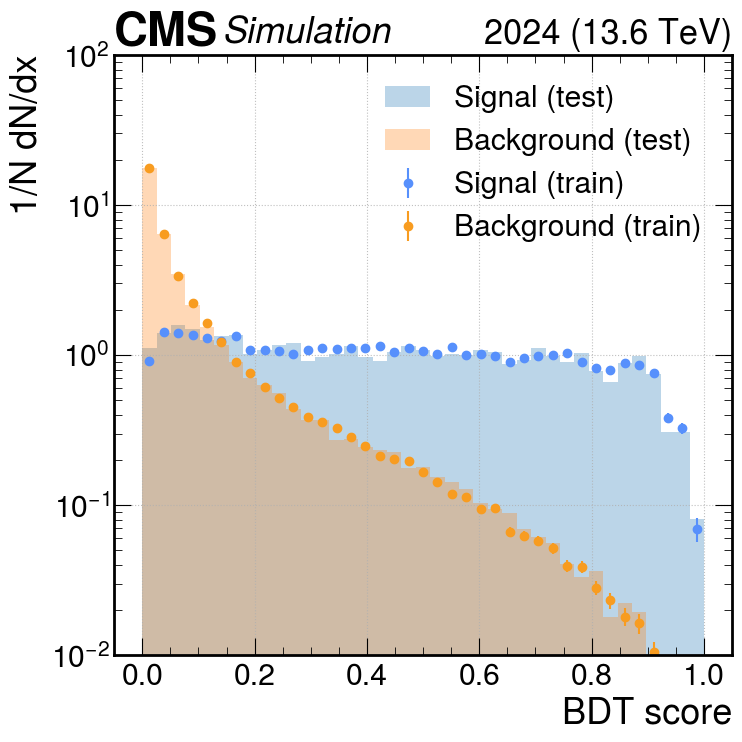

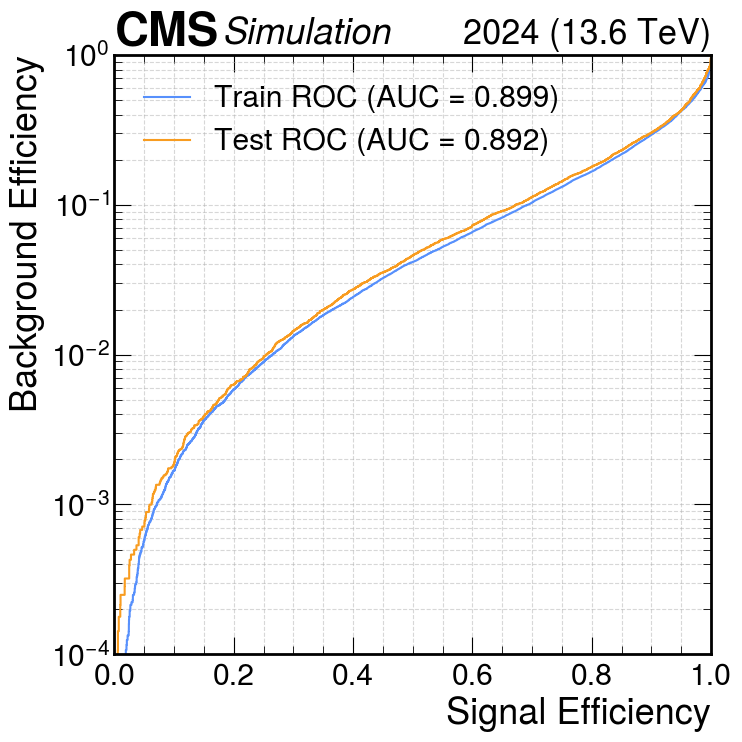

In [30]:
# =================== Train one final model + plots ===================

dtrain_full = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_NAMES)
dtest_full  = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURE_NAMES)

bst_full = xgb.train(
    params=xgb_params,
    dtrain=dtrain_full,
    num_boost_round=num_boost_round,
    evals=[(dtest_full, "test")],
    verbose_eval=False,
)

y_train_prob = bst_full.predict(dtrain_full)
y_test_prob  = bst_full.predict(dtest_full)

# ---- BDT score distributions ----
train_sig = y_train_prob[y_train == 1]
train_bkg = y_train_prob[y_train == 0]
test_sig  = y_test_prob[y_test == 1]
test_bkg  = y_test_prob[y_test == 0]

bins = np.linspace(0.0, 1.0, 40)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths  = np.diff(bins)

def hist_with_errors(values, bins_):
    counts, _ = np.histogram(values, bins=bins_)
    N = counts.sum()
    if N == 0:
        return np.zeros_like(counts, dtype=float), np.zeros_like(counts, dtype=float)
    density = counts / (N * bin_widths)
    err = np.sqrt(counts) / (N * bin_widths)
    return density, err

dens_tr_sig, err_tr_sig = hist_with_errors(train_sig, bins)
dens_tr_bkg, err_tr_bkg = hist_with_errors(train_bkg, bins)

fig, ax = plt.subplots(figsize=(8, 8))
add_cms_sim_label(ax)
signal_color = "tab:blue"
bkg_color    = "tab:orange"

ax.errorbar(bin_centers, dens_tr_sig, yerr=err_tr_sig, fmt="o", label="Signal (train)")
ax.errorbar(bin_centers, dens_tr_bkg, yerr=err_tr_bkg, fmt="o", label="Background (train)")

ax.hist(test_sig, bins=bins, histtype="stepfilled", alpha=0.3, density=True, label="Signal (test)", color=signal_color)
ax.hist(test_bkg, bins=bins, histtype="stepfilled", alpha=0.3, density=True, label="Background (test)", color=bkg_color)

ax.set_yscale("log")
ax.set_xlabel("BDT score", ha="right", x=1.0)
ax.set_ylabel("1/N dN/dx", ha="right", y=1.0)
ax.set_ylim(1e-2, 1e2)
ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "bdt_score_log_train_test_sig_bkg.pdf"))
plt.show()

# ---- ROC (signal eff vs background eff) ----
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_prob)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_prob)

auc_train_final = roc_auc_score(y_train, y_train_prob)
auc_test_final  = roc_auc_score(y_test,  y_test_prob)

fig, ax = plt.subplots(figsize=(8, 8))
add_cms_sim_label(ax)

# X = signal efficiency (TPR), Y = background efficiency (FPR)
ax.plot(tpr_tr, fpr_tr, label=f"Train ROC (AUC = {auc_train_final:.3f})")
ax.plot(tpr_te, fpr_te, label=f"Test ROC (AUC = {auc_test_final:.3f})")

ax.set_xlabel("Signal Efficiency")
ax.set_ylabel("Background Efficiency")
ax.set_xlim(0, 1)
ax.set_ylim(1e-4, 1)
ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "roc_sigEff_vs_bkgEff.pdf"))
plt.show()